# Ground-to-UAV Geometry and Sionna RT

This notebook turns the abstract speed parameter from Notebook 3 into one explicit radio link:

```text
stationary ground LoRa transmitter -> moving UAV LoRa receiver
```

The UAV follows a fixed-altitude route in a local east-north-up (ENU) coordinate system. We animate the geometry, derive range, elevation, radial speed, and Doppler, and then ask Sionna RT to reproduce the free-space delay, Doppler, and path gain. The experiment is SISO: one antenna at each end.

Ground reflection, buildings, measured airframe shadowing, and electronic interference are deliberately postponed. An empty RT scene gives us a clean baseline that later scenes must reproduce when their extra mechanisms are disabled.

## 1. Define one flight in local coordinates

Sionna RT expects positions in metres, not latitude and longitude in degrees. For a real flight, first transform GNSS coordinates into a local ENU frame whose origin is a surveyed site reference. The small-area approximation below is adequate for visualizing a short tutorial route; a real campaign should use its documented geodetic projection.

The synthetic UAV flies east at constant altitude and passes 15 m north of the ground node. This near-overhead pass makes both the Doppler sign change and the vertical-dipole pattern visible.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import HTML
from matplotlib.animation import FuncAnimation

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

C = 299_792_458.0
EARTH_RADIUS_M = 6_371_000.0
FC_HZ = 2.44e9
BW_HZ = 812_500.0
GROUND_TX = np.array([0.0, 0.0, 1.5])
UAV_ALTITUDE_M = 30.0

def latlon_to_local_enu(latitude_deg, longitude_deg, altitude_m, origin):
    """Small-area latitude/longitude conversion for visualization only."""
    lat0_deg, lon0_deg, alt0_m = origin
    dlat = np.deg2rad(np.asarray(latitude_deg) - lat0_deg)
    dlon = np.deg2rad(np.asarray(longitude_deg) - lon0_deg)
    east = EARTH_RADIUS_M * np.cos(np.deg2rad(lat0_deg)) * dlon
    north = EARTH_RADIUS_M * dlat
    up = np.asarray(altitude_m) - alt0_m
    return np.stack(np.broadcast_arrays(east, north, up), axis=-1)

origin = (3.1390, 101.6869, 0.0)
assert np.allclose(latlon_to_local_enu(*origin, origin), 0.0)
print(f"Carrier wavelength: {C / FC_HZ:.3f} m")

Carrier wavelength: 0.123 m


In [11]:
NUM_SAMPLES = 81
flight_time_s = np.linspace(0.0, 40.0, NUM_SAMPLES)
uav_position = np.column_stack([
    np.linspace(-150.0, 150.0, NUM_SAMPLES),
    np.full(NUM_SAMPLES, 15.0),
    np.full(NUM_SAMPLES, UAV_ALTITUDE_M),
])
uav_velocity = np.gradient(uav_position, flight_time_s, axis=0)

link_vector = uav_position - GROUND_TX
distance_m = np.linalg.norm(link_vector, axis=1)
horizontal_distance_m = np.linalg.norm(link_vector[:, :2], axis=1)
los_unit = link_vector / distance_m[:, None]
range_rate_mps = np.sum(uav_velocity * los_unit, axis=1)
closing_speed_mps = -range_rate_mps
doppler_hz = closing_speed_mps * FC_HZ / C
elevation_deg = np.rad2deg(np.arctan2(link_vector[:, 2], horizontal_distance_m))
fspl_db = 20 * np.log10(4 * np.pi * distance_m * FC_HZ / C)

closest = np.argmin(distance_m)
assert np.allclose(np.linalg.norm(uav_velocity[:, :2], axis=1), 7.5)
assert abs(doppler_hz[closest]) < 1e-9
print(f"Closest approach: {distance_m[closest]:.1f} m at t={flight_time_s[closest]:.1f} s")
print(f"Maximum |Doppler|: {np.max(np.abs(doppler_hz)):.1f} Hz")

Closest approach: 32.2 m at t=20.0 s
Maximum |Doppler|: 59.7 Hz


The UAV ground speed is 7.5 m/s throughout the flight, but Doppler depends on **closing speed**, the component of velocity along the radio path. Approaching the node gives positive Doppler in our convention, closest approach gives zero, and receding gives negative Doppler.

For LoRa, compare Doppler with the post-dechirp FFT-bin spacing

$$R_s=\frac{BW}{2^{SF}}.
$$

A large $|f_D|/R_s$ warns that an uncompensated detector may lose energy from the intended bin. It does not directly equal SER; synchronization, multipath, SNR, and coding still matter.

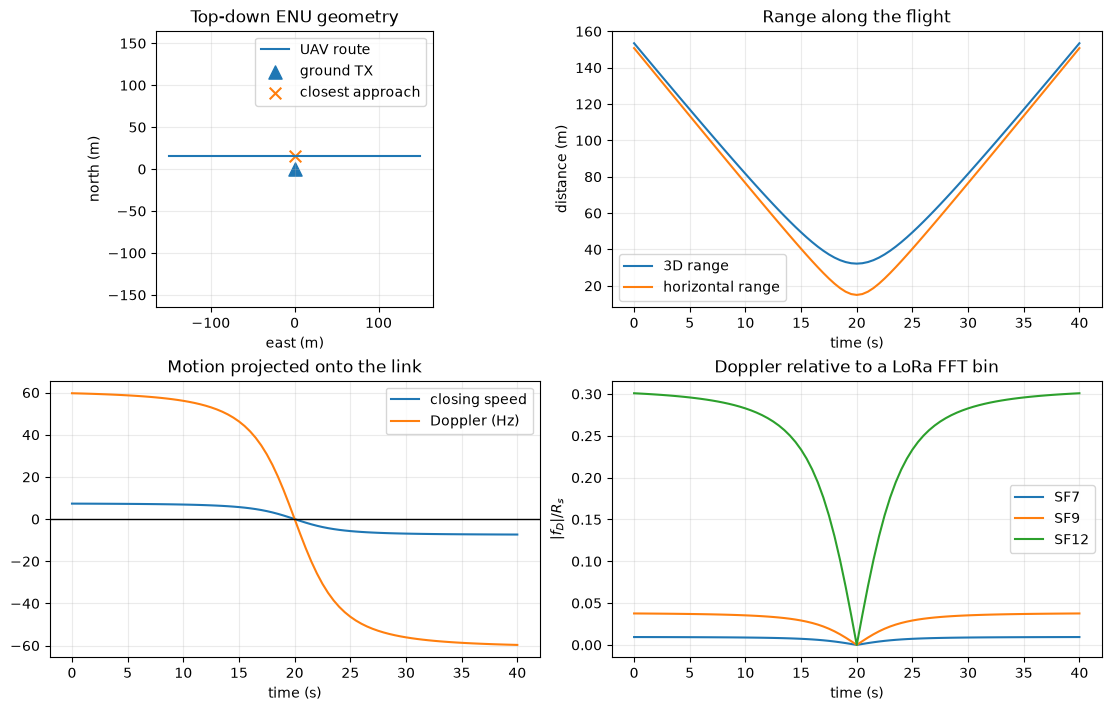

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

axes[0, 0].plot(uav_position[:, 0], uav_position[:, 1], label="UAV route")
axes[0, 0].scatter(*GROUND_TX[:2], marker="^", s=90, label="ground TX")
axes[0, 0].scatter(*uav_position[closest, :2], marker="x", s=70, label="closest approach")
axes[0, 0].set(title="Top-down ENU geometry", xlabel="east (m)", ylabel="north (m)", xlim=(-165, 165), ylim=(-165, 165), aspect="equal")
axes[0, 0].legend()

axes[0, 1].plot(flight_time_s, distance_m, label="3D range")
axes[0, 1].plot(flight_time_s, horizontal_distance_m, label="horizontal range")
axes[0, 1].set(title="Range along the flight", xlabel="time (s)", ylabel="distance (m)")
axes[0, 1].legend()

axes[1, 0].plot(flight_time_s, closing_speed_mps, label="closing speed")
axes[1, 0].plot(flight_time_s, doppler_hz, label="Doppler (Hz)")
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set(title="Motion projected onto the link", xlabel="time (s)")
axes[1, 0].legend()

for sf in (7, 9, 12):
    bin_spacing_hz = BW_HZ / (1 << sf)
    axes[1, 1].plot(flight_time_s, np.abs(doppler_hz) / bin_spacing_hz, label=f"SF{sf}")
axes[1, 1].set(title="Doppler relative to a LoRa FFT bin", xlabel="time (s)", ylabel=r"$|f_D|/R_s$")
axes[1, 1].legend()
plt.show()

## 2. Animate the geometry

The left panel is the fixed-altitude UAV track relative to the ground transmitter. The right panel shows why ground speed and radio Doppler are not interchangeable: Doppler crosses zero at closest approach even though the UAV never stops.

In [13]:
fig, (ax_map, ax_doppler) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

ax_map.plot(uav_position[:, 0], uav_position[:, 1], color="0.75", label="planned route")
ax_map.scatter(*GROUND_TX[:2], marker="^", s=100, color="C3", label="ground TX")
trail, = ax_map.plot([], [], color="C0", linewidth=2, label="flown")
link, = ax_map.plot([], [], color="C1", linestyle="--", linewidth=1)
uav_marker, = ax_map.plot([], [], marker="o", color="C0", markersize=8, linestyle="None", label="UAV RX")
status = ax_map.text(0.02, 0.98, "", transform=ax_map.transAxes, va="top")
ax_map.set(xlim=(-165, 165), ylim=(-165, 165), xlabel="east (m)", ylabel="north (m)", title=f"Fixed altitude: {UAV_ALTITUDE_M:.0f} m")
ax_map.set_aspect("equal", adjustable="box")
ax_map.legend(loc="lower right")

ax_doppler.plot(flight_time_s, doppler_hz, color="C2")
doppler_marker, = ax_doppler.plot([], [], marker="o", color="C2", linestyle="None")
ax_doppler.axhline(0, color="black", linewidth=1)
ax_doppler.set(xlim=(flight_time_s[0], flight_time_s[-1]), ylim=(1.15 * doppler_hz.min(), 1.15 * doppler_hz.max()), xlabel="time (s)", ylabel="Doppler (Hz)", title="LoS Doppler seen by the UAV receiver")

def update(frame):
    east, north, _ = uav_position[frame]
    trail.set_data(uav_position[:frame + 1, 0], uav_position[:frame + 1, 1])
    link.set_data([GROUND_TX[0], east], [GROUND_TX[1], north])
    uav_marker.set_data([east], [north])
    doppler_marker.set_data([flight_time_s[frame]], [doppler_hz[frame]])
    status.set_text(
        f"t = {flight_time_s[frame]:.1f} s\n"
        f"range = {distance_m[frame]:.1f} m\n"
        f"elevation = {elevation_deg[frame]:.1f} deg\n"
        f"closing speed = {closing_speed_mps[frame]:+.2f} m/s"
    )
    return trail, link, uav_marker, doppler_marker, status

animation = FuncAnimation(fig, update, frames=NUM_SAMPLES, interval=80, blit=True)
plt.close(fig)
HTML(animation.to_jshtml())

## 3. Is Doppler a vector? What changes on an orbit?

Doppler shift is a **scalar for each propagation path**, not a spatial vector. The relative velocity $\mathbf{v}$ and path direction $\hat{\mathbf{k}}$ are vectors; their dot product produces the scalar closing speed and Doppler:

$$v_r=-\mathbf{v}^{\mathsf T}\hat{\mathbf{k}}, \qquad f_D=\frac{v_r}{\lambda}.
$$

Doppler then makes the complex path coefficient rotate with time:

$$a_p(t)=a_p(0)e^{j2\pi f_{D,p}t}.
$$

The rotating complex phasor can be drawn as a two-dimensional arrow in the I/Q plane, but the physical Doppler frequency $f_{D,p}$ is still one scalar per path.

For a level circular orbit centered exactly over the ground transmitter, velocity is tangential while the line of sight is radial. Their dot product is zero. The UAV can therefore move quickly with essentially zero line-of-sight Doppler. This statement does not extend automatically to reflected paths, an off-center orbit, changing altitude, or wind drift.

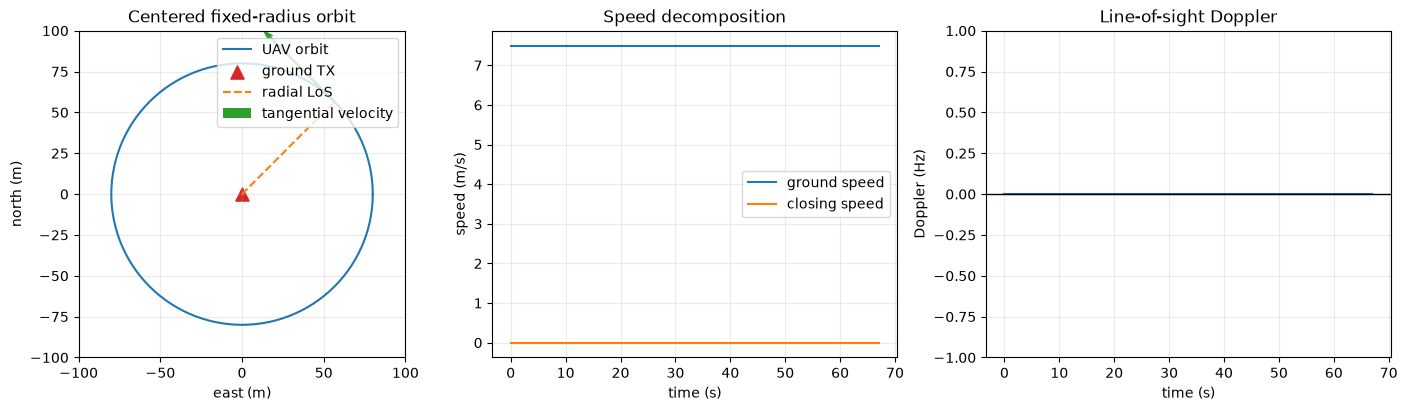

3D orbit range: 84.9 m
Maximum numerical |LoS Doppler|: 7.23e-15 Hz


In [14]:
ORBIT_RADIUS_M = 80.0
ORBIT_SPEED_MPS = 7.5
ORBIT_SAMPLES = 121
orbit_period_s = 2 * np.pi * ORBIT_RADIUS_M / ORBIT_SPEED_MPS
orbit_time_s = np.linspace(0.0, orbit_period_s, ORBIT_SAMPLES)
orbit_angle = 2 * np.pi * orbit_time_s / orbit_period_s
orbit_position = np.column_stack([
    ORBIT_RADIUS_M * np.cos(orbit_angle),
    ORBIT_RADIUS_M * np.sin(orbit_angle),
    np.full(ORBIT_SAMPLES, UAV_ALTITUDE_M),
])
orbit_velocity = np.column_stack([
    -ORBIT_SPEED_MPS * np.sin(orbit_angle),
    ORBIT_SPEED_MPS * np.cos(orbit_angle),
    np.zeros(ORBIT_SAMPLES),
])
orbit_link = orbit_position - GROUND_TX
orbit_distance_m = np.linalg.norm(orbit_link, axis=1)
orbit_los_unit = orbit_link / orbit_distance_m[:, None]
orbit_closing_speed_mps = -np.sum(orbit_velocity * orbit_los_unit, axis=1)
orbit_doppler_hz = orbit_closing_speed_mps * FC_HZ / C
orbit_ground_speed_mps = np.linalg.norm(orbit_velocity, axis=1)

assert np.allclose(orbit_distance_m, orbit_distance_m[0])
assert np.max(np.abs(orbit_doppler_hz)) < 1e-10

example = ORBIT_SAMPLES // 8
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].plot(orbit_position[:, 0], orbit_position[:, 1], label="UAV orbit")
axes[0].scatter(*GROUND_TX[:2], marker="^", s=90, color="C3", label="ground TX")
axes[0].plot([0, orbit_position[example, 0]], [0, orbit_position[example, 1]], "C1--", label="radial LoS")
axes[0].quiver(orbit_position[example, 0], orbit_position[example, 1], orbit_velocity[example, 0], orbit_velocity[example, 1], color="C2", scale=0.12, scale_units="xy", angles="xy", label="tangential velocity")
axes[0].set(title="Centered fixed-radius orbit", xlabel="east (m)", ylabel="north (m)", xlim=(-100, 100), ylim=(-100, 100), aspect="equal")
axes[0].legend(loc="upper right")

axes[1].plot(orbit_time_s, orbit_ground_speed_mps, label="ground speed")
axes[1].plot(orbit_time_s, orbit_closing_speed_mps, label="closing speed")
axes[1].set(title="Speed decomposition", xlabel="time (s)", ylabel="speed (m/s)")
axes[1].legend()

axes[2].plot(orbit_time_s, orbit_doppler_hz)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set(title="Line-of-sight Doppler", xlabel="time (s)", ylabel="Doppler (Hz)", ylim=(-1, 1))
plt.show()

print(f"3D orbit range: {orbit_distance_m[0]:.1f} m")
print(f"Maximum numerical |LoS Doppler|: {np.max(np.abs(orbit_doppler_hz)):.2e} Hz")

## 4. A first antenna-orientation effect

An ideal vertical short dipole does not radiate equally in every direction. If $\theta$ is the angle from its vertical axis, its normalized power gain is

$$G(\theta)=1.5\sin^2(\theta).$$

It is strongest toward the horizon and has a null directly above or below the antenna. With level, vertically aligned antennas at both ends, a near-overhead UAV can therefore lose power even while its geometric distance is smallest. This is an antenna-pattern effect, not obstacle blockage.

The simple calculation below assumes both antennas remain vertical. Full roll, pitch, yaw, polarization mismatch, and measured airframe shadowing belong in the next scene-calibration notebook.

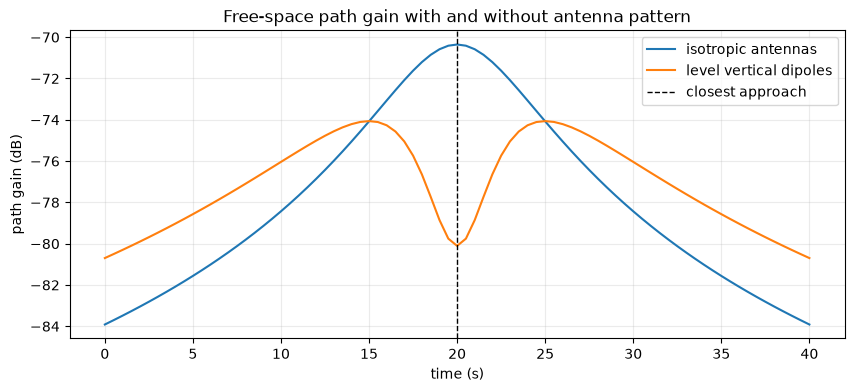

In [15]:
theta_from_vertical = np.arccos(np.clip(np.abs(link_vector[:, 2]) / distance_m, 0.0, 1.0))
single_dipole_gain = 1.5 * np.sin(theta_from_vertical) ** 2
dipole_pair_gain_db = 10 * np.log10(np.maximum(single_dipole_gain ** 2, 1e-12))
isotropic_path_gain_db = -fspl_db
vertical_dipole_path_gain_db = isotropic_path_gain_db + dipole_pair_gain_db

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(flight_time_s, isotropic_path_gain_db, label="isotropic antennas")
ax.plot(flight_time_s, vertical_dipole_path_gain_db, label="level vertical dipoles")
ax.axvline(flight_time_s[closest], color="black", linestyle="--", linewidth=1, label="closest approach")
ax.set(title="Free-space path gain with and without antenna pattern", xlabel="time (s)", ylabel="path gain (dB)")
ax.legend()
plt.show()

### The nearest waypoint may sit in an antenna null

The side view shows the actual height and horizontal range at closest approach. The polar plot is a meridional slice of the same short-dipole power pattern used above, with angle measured from vertical. Both endpoints' patterns and polarization enter the link. An elevated collector can improve visibility, but flying directly over a vertical antenna can reduce gain; this benefit/cost is geometry-dependent.

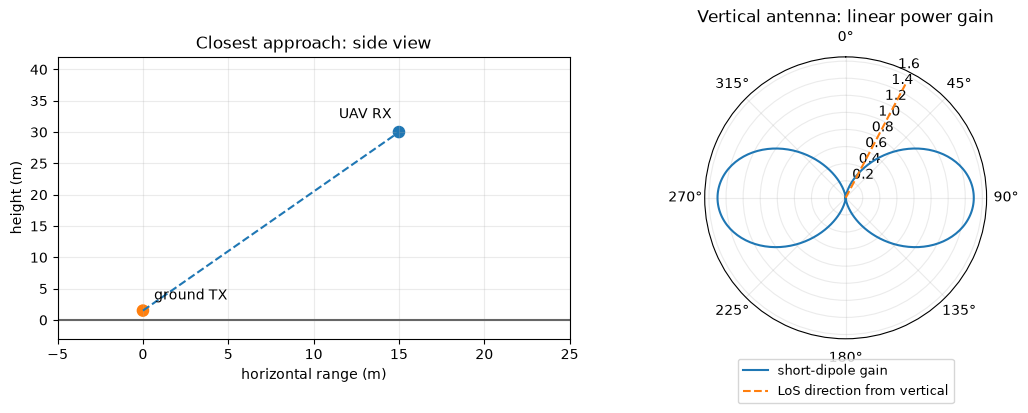

In [16]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)
ax_side = fig.add_subplot(121)
ax_pattern = fig.add_subplot(122, projection='polar')
demo_r = horizontal_distance_m[closest]
ax_side.plot([0, demo_r], [GROUND_TX[2], UAV_ALTITUDE_M], 'C0--', label='LoS')
ax_side.scatter([0, demo_r], [GROUND_TX[2], UAV_ALTITUDE_M], c=['C1', 'C0'], s=65)
ax_side.annotate('ground TX', (0, GROUND_TX[2]), xytext=(8, 8), textcoords='offset points')
ax_side.annotate('UAV RX', (demo_r, UAV_ALTITUDE_M), xytext=(-5, 10), textcoords='offset points', ha='right')
ax_side.axhline(0, color='0.4')
ax_side.set(xlim=(-5, max(25, demo_r + 8)), ylim=(-3, UAV_ALTITUDE_M + 12), xlabel='horizontal range (m)', ylabel='height (m)', title='Closest approach: side view')
angles = np.linspace(0, 2 * np.pi, 361)
ax_pattern.set_theta_zero_location('N')
ax_pattern.set_theta_direction(-1)
ax_pattern.plot(angles, 1.5 * np.sin(angles)**2, label='short-dipole gain')
demo_theta = theta_from_vertical[closest]
ax_pattern.plot([demo_theta, demo_theta], [0, 1.5], 'C1--', label='LoS direction from vertical')
ax_pattern.set(title='Vertical antenna: linear power gain', rlim=(0, 1.65))
ax_pattern.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), fontsize=9)
plt.show()

## 5. Verify selected positions with Sionna RT

We now create an empty Sionna RT scene. Empty means no ground mesh or buildings, so the path solver can produce only the line-of-sight path. Seventeen receivers are placed at selected waypoints only to evaluate the entire route efficiently; they represent seventeen times along one UAV flight, not seventeen physical UAVs.

We solve the same geometry twice: first with isotropic antennas for a Friis baseline, then with vertical dipoles. Sionna RT also uses each receiver's velocity vector to calculate path Doppler.

In [17]:
from sionna.rt import PathSolver, PlanarArray, Receiver, Transmitter, load_scene

RT_INDICES = np.linspace(0, NUM_SAMPLES - 1, 17, dtype=int)

def solve_free_space_route(pattern):
    scene = load_scene()
    scene.frequency = FC_HZ
    scene.bandwidth = BW_HZ
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern=pattern, polarization="V")
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern=pattern, polarization="V")
    scene.add(Transmitter("ground-tx", position=GROUND_TX, orientation=[0, 0, 0]))

    for waypoint, route_index in enumerate(RT_INDICES):
        scene.add(Receiver(
            f"uav-rx-{waypoint:02d}",
            position=uav_position[route_index],
            orientation=[0, 0, 0],
            velocity=uav_velocity[route_index],
        ))

    paths = PathSolver(deterministic=True)(
        scene,
        max_depth=0,
        los=True,
        specular_reflection=False,
        diffuse_reflection=False,
        refraction=False,
        diffraction=False,
    )
    a, tau = paths.cir(normalize_delays=False, out_type="numpy")
    path_gain = np.sum(np.abs(a) ** 2, axis=tuple(range(1, a.ndim)))
    return {
        "path_gain_db": 10 * np.log10(np.maximum(path_gain, 1e-30)),
        "delay_s": tau.reshape(len(RT_INDICES), -1)[:, 0],
        "doppler_hz": paths.doppler.numpy().reshape(len(RT_INDICES), -1)[:, 0],
    }

rt_iso = solve_free_space_route("iso")
rt_dipole = solve_free_space_route("dipole")
expected_delay_s = distance_m[RT_INDICES] / C
assert np.allclose(rt_iso["delay_s"], expected_delay_s, atol=1e-9)
print("Sionna RT line-of-sight delay check passed.")

Sionna RT line-of-sight delay check passed.


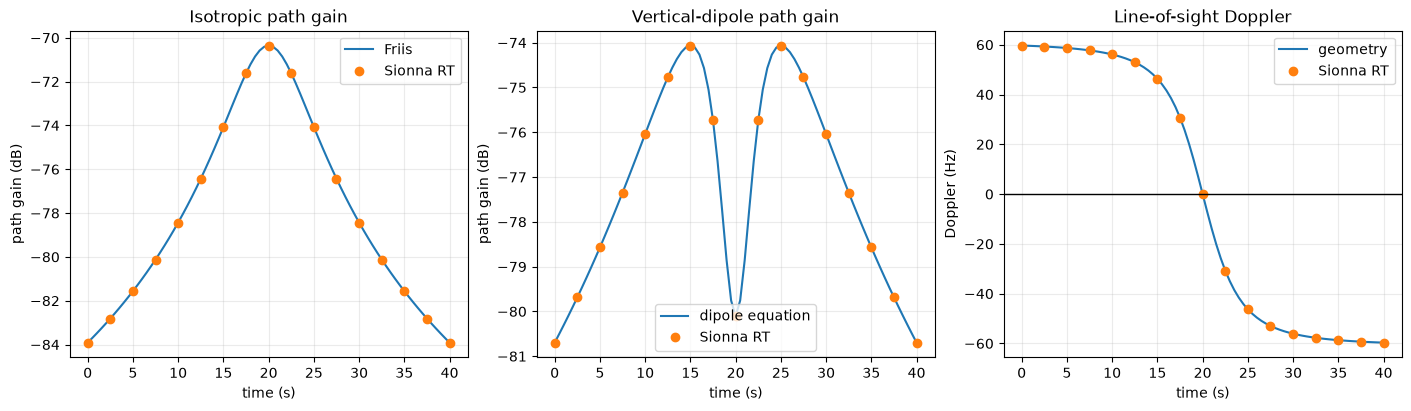

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
sample_time = flight_time_s[RT_INDICES]

axes[0].plot(flight_time_s, isotropic_path_gain_db, label="Friis")
axes[0].plot(sample_time, rt_iso["path_gain_db"], "o", label="Sionna RT")
axes[0].set(title="Isotropic path gain", xlabel="time (s)", ylabel="path gain (dB)")
axes[0].legend()

axes[1].plot(flight_time_s, vertical_dipole_path_gain_db, label="dipole equation")
axes[1].plot(sample_time, rt_dipole["path_gain_db"], "o", label="Sionna RT")
axes[1].set(title="Vertical-dipole path gain", xlabel="time (s)", ylabel="path gain (dB)")
axes[1].legend()

axes[2].plot(flight_time_s, doppler_hz, label="geometry")
axes[2].plot(sample_time, rt_iso["doppler_hz"], "o", label="Sionna RT")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set(title="Line-of-sight Doppler", xlabel="time (s)", ylabel="Doppler (Hz)")
axes[2].legend()
plt.show()

## 6. TLDR

This is a controlled geometry baseline, not a calibrated UAV channel or packet-delivery prediction. There is absence of:-

- **Ground reflection and materials**
- **UAV attitude and airframe:** replace the fixed level orientation with timestamped roll, pitch, and yaw. Measured airframe shadowing may be represented through a calibrated antenna pattern or an empirical correction.
- **Drone EMI:** RT does not create ESC, motor, regulator, or digital-electronics emissions. Model measured motor-off/motor-on receiver desensitization as added noise, noise-figure change, or explicit spectral interferers in Notebook 6.
- **External radios:** co-SF LoRa, cross-SF LoRa, adjacent channels, and Wi-Fi are additional transmitted waveforms, also handled in Notebook 6.
- **SER/PER:** geometry and RT produce a channel. Feed its CIR into the LoRa waveform and packet receiver from Notebooks 1-3 before claiming symbol or packet reliability.

## Takeaways

- Notebook 4 models one ground transmitter and one moving UAV receiver.
- Doppler depends on radial velocity, not total UAV speed; a centered fixed-radius orbit has zero line-of-sight Doppler in the ideal geometry.
- A vertical antenna can be weakest near an overhead pass even when range is shortest.
- Sionna RT supplies path delay, gain, angles, and Doppler; the LoRa PHY determines whether the resulting chirp or packet is decoded.

## Focused references

- Sionna [electromagnetics primer](https://nvlabs.github.io/sionna/rt/em_primer.html): Friis, antenna gain, polarization, and motion. These govern LoRa propagation too.
- [Data collection from LoRaWAN sensor network by UAV gateway: design, empirical results and dataset](https://oulurepo.oulu.fi/handle/10024/44321): a field-study counterpart for the airborne-receiver use case; compare its geometry and packet metrics with this controlled baseline.